# Imports and load data
this notebook contains the training and validation losses per epoch, and also the F1 score obtained with the validation set and with the family held-out for the different models, and datasets used to train the sincFold model.

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(
    "ignore",
    message="The figure layout has changed to tight"
)


METRICS_PATH = Path("../results/metrics_all.csv")
metrics_all = pd.read_csv(METRICS_PATH)

# Plotting functions

In [73]:
def smooth_curve(y, window=5):
    return y.rolling(window=window, center=True, min_periods=1).mean()

def plot_loss_and_f1_across_datasets(
    metrics, 
    strategies, 
    fams,
    title="Train/Valid Loss and Valid/Test F1 by family", 
    figsize=(6.5, 2.5),  
    save=False, 
    save_title="loss_f1_comparison.png" 
): 
    plt.rcParams.update({'font.size': 7})
    n_fams = len(fams)
    rows, cols = 2, n_fams

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(6.5, 2.5),
        constrained_layout=True,
        sharex=True,
        sharey="row"
    ) 
    base_colors = ['gray', 'green', 'purple', 'orange', 'brown', 'blue']
 
    for col, fam in enumerate(fams):


        # row 0: Loss
        ax_loss = axes[0, col]
        for i, strategy in enumerate(strategies):
            df = metrics.query("strategy == @strategy and fam == @fam")
            color = base_colors[i % len(base_colors)]
 
            ax_loss.plot(df['epoch'],
                        smooth_curve(df['train_loss']),
                        label=strategy, 
                        color=color,
                        linewidth=1)
            
            ax_loss.plot(df['epoch'], 
                        smooth_curve(df['valid_loss']),
                        color=color,
                        linewidth=1,
                        linestyle="--")
           

        ax_loss.set_title(fam, fontsize=7 )
        ax_loss.set_xlim(0, 25)
        ax_loss.grid(False)

        # row 1: F1 score
        ax_f1 = axes[1, col]
        for i, strategy in enumerate(strategies):
            df = metrics.query("strategy == @strategy and fam == @fam")
            color = base_colors[i % len(base_colors)]
            
            ax_f1.plot(df['epoch'],
                        smooth_curve(df['valid_f1']),
                        color=color,
                        linewidth=1,
                        linestyle="--",
                        label=f"F1 ({strategy})")
            
 
            # test f1 points
            test_rows = df['test_f1'].notna()
            ax_f1.scatter(
                df.loc[test_rows, 'epoch'],
                df.loc[test_rows, 'test_f1'],
                color=color, s=3.5,
                marker='o' if i == 0 else 'x', # different marker for full dataset
                label=None
            )

        ax_f1.set_ylim(0, 1)
        ax_f1.set_xlim(0, 25)
        ax_f1.set_xlabel("Epoch", fontsize=6)
        ax_f1.grid(False)

        if col == 0:
            ax_loss.set_ylabel("Loss",   fontsize=6)
            ax_f1.set_ylabel("F1 Score", fontsize=6)

        ax_f1.set_xlabel("Epoch", fontsize=6)
 
    handles, labels = axes[0, -1].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(0.985, 0.81),
        # ncol=len(strategies),
        frameon=True,
        fontsize=5,
        # handlelength=1.2,
        handletextpad=0.3,
        # columnspacing=0.8,
        labelspacing=0.2,
    )

    fig.suptitle(title, fontsize=6)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if save:
        fig.savefig(save_title  , dpi=300)

    plt.show()


In [74]:
fams = ['5s', 'tRNA',  'tmRNA',   'RNaseP','srp',  'telomerase', 'grp1', '23s', '16s', ]
fams_selected = ['tRNA', 'srp', 'telomerase',  'grp1', '23s']
fams_others = ['5s', 'tmRNA', 'RNaseP', '16s',]

 
dataset_sortS = ["full", "sortS100", "sortS200", "sortS400"] 
dataset_clusS = ["full", "clusS100", "clusS200", "clusS400"]
dataset_thr100 = ["full", "sortS100", "clusS100", "randS100"]


# training metrics: sincFold

## strategy: sortS

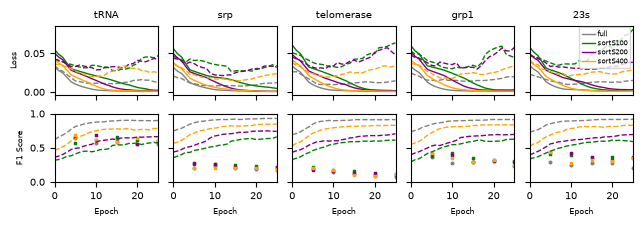

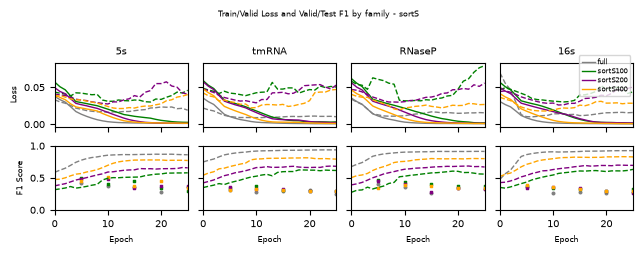

In [76]:
# Train/Valid Loss and Valid/Test F1 by family - sortS
metrics = metrics_all.query("model == 'sincFold'").copy()
plot_loss_and_f1_across_datasets(
    metrics=metrics,
    strategies=dataset_sortS,
    fams=fams_selected,
    title="",
    save=True,
    save_title="../figures/3A.svg"
)

plot_loss_and_f1_across_datasets(
    metrics=metrics,
    strategies=dataset_sortS,
    fams=fams_others,
    title="Train/Valid Loss and Valid/Test F1 by family - sortS",
)

## threshold: K=100

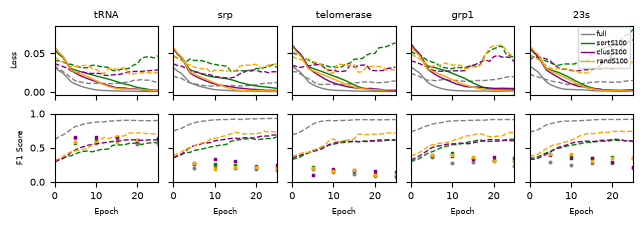

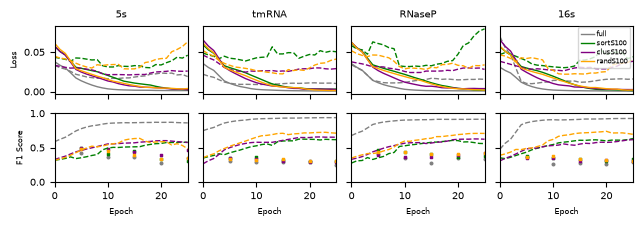

In [77]:
# Train/Valid Loss and Valid/Test F1 by family - threshold 100
plot_loss_and_f1_across_datasets(
    metrics=metrics,
    strategies=dataset_thr100,
    fams=fams_selected,
    title="",
    save=True,
    save_title="../figures/3B.svg"
)
# Train/Valid Loss and Valid/Test F1 by family - threshold 100
plot_loss_and_f1_across_datasets(
    metrics=metrics,
    strategies=dataset_thr100,
    fams=fams_others,    
    title="",

)